In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [3]:
circuito1 = np.zeros(shape=(32, 17))
# Salida
circuito1[-1, 3:9] = 2
# Meta
circuito1[:6, -1] = 3
# Pista
circuito1[:-1, 3:9] = 1
circuito1[:7, 9] = 1
circuito1[:6, 10:-1] = 1
circuito1[1:-3, 2] = 1
circuito1[3:-10, 1] = 1
circuito1[4:14, 0] = 1


In [4]:
circuito2 = np.zeros(shape=(30, 32))
# Salida
circuito2[-1, :-9] = 2
# Meta
circuito2[:9, -1] = 3
# Pista
circuito2[1:-1, 14:16] = 1
circuito2[:-1, 16:23] = 1
for j in range(0, 14):
    circuito2[-3-j:-1, j] = 1
circuito2[1:9, 13] = 1
circuito2[2:8, 12] = 1
circuito2[3:7, 11] = 1
circuito2[:9, -9:-1] = 1
circuito2[9, -9:-2] = 1
circuito2[10, -9:-5] = 1
circuito2[11, -9:-6] = 1
circuito2[12, -9:-8] = 1


In [269]:
class Carrera:
    def __init__(self, circuito, gamma, eps, Q_inicial):

        self.circuito = np.flipud(circuito).T.astype(int) # Transforma el array para que la celda inferior izquiera sea [0, 0]
        self.circuito_dibujo = circuito
        self.estado = self.salida_aleatoria()
        self.acciones = [(ax, ay) for ax in [-1, 0, 1] for ay in [-1, 0, 1]]
        self.gamma = gamma
        self.eps = eps
        self.Q_inicial = Q_inicial

    
    def salida_aleatoria(self):
        celdas_salida = list(zip(*np.where(self.circuito == 2)))
        pos = random.choice(celdas_salida)
        estado = (int(pos[0]), int(pos[1]), 0, 0)
        return estado
    
    
    def visualizar_circuito(self):
        TAM_CELDA = 20
        COLORES = {
            0: (0, 0, 0),       # Muro -> Negro
            1: (255, 255, 255), # Pista -> Blanco
            2: (255, 0, 0),     # Salida -> Rojo
            3: (0, 255, 0),     # Meta -> Verde
        }

        h, w = self.circuito_dibujo.shape
        img = np.zeros((h * TAM_CELDA, w * TAM_CELDA, 3), dtype=np.uint8)

        # Dibuja las celdas del circuito
        for i in range(h):
            for j in range(w):
                color = COLORES[self.circuito_dibujo[i, j]]
                y1, y2 = i * TAM_CELDA, (i + 1) * TAM_CELDA
                x1, x2 = j * TAM_CELDA, (j + 1) * TAM_CELDA
                img[y1:y2, x1:x2] = color

        # Dibuja una rejilla para diferenciar las celdas
        for i in range(h + 1):
            y = i * TAM_CELDA
            cv2.line(img, (0, y), (w * TAM_CELDA, y), (200, 200, 200), 1)

        for j in range(w + 1):
            x = j * TAM_CELDA
            cv2.line(img, (x, 0), (x, h * TAM_CELDA), (200, 200, 200), 1)

        return img
    

    def acciones_posibles(self, estado):
        x, y, vx, vy = estado
        lista_acciones_posibles = []
        for accion in self.acciones:
            new_v = vx + accion[0], vy + accion[1]
            if (new_v[0] >= 0) and (new_v[0] < 5) and (new_v[1] >= 0) and (new_v[1] < 5) and not (new_v[0] == 0 and new_v[1] == 0):
                lista_acciones_posibles.append(accion)
        return lista_acciones_posibles
    

    def trayectoria(self, x, y, vx, vy):
        n_casillas = max(abs(vx), abs(vy))
        casillas = []
        if n_casillas >= 1:
            for i in range(1, n_casillas + 1):
                xi = x + int(vx * i / n_casillas + 0.5)
                yi = y + int(vy * i / n_casillas + 0.5)
                casillas.append((xi, yi))
        
        return casillas
    

    def paso(self, accion):
        x, y, vx, vy = self.estado
        ax, ay = accion

        new_vx = vx + ax
        new_vy = vy + ay

        trayectoria = self.trayectoria(x, y, new_vx, new_vy)

        for xi, yi in trayectoria:
            nx, ny = self.circuito.shape
            if xi >= nx or yi >= ny:
                self.estado = self.salida_aleatoria()
                return -1
            elif self.circuito[xi, yi] == 0:
                self.estado = self.salida_aleatoria()
                return -1
            elif self.circuito[xi, yi] == 3:
                self.estado = xi, yi, new_vx, new_vy
                return -1

        self.estado = xi, yi, new_vx, new_vy
        return -1

    
    def politica_objetivo(self, Q, estado):
        acciones = self.acciones_posibles(estado)
        valores = [Q[(estado, a)] if (estado, a) in Q else self.Q_inicial for a in acciones]
        return acciones[np.argmax(valores)]
    

    def politica_soft(self, Q, estado):
        acciones = self.acciones_posibles(estado)

        if random.random() < self.eps:
            accion = random.choice(acciones)
            if accion == self.politica_objetivo(Q, estado):
                prob_accion = 1 - self.eps + self.eps / (len(acciones))
            else:
                prob_accion = self.eps / (len(acciones))
            return accion, prob_accion
        else:
            accion = self.politica_objetivo(Q, estado)
            prob_accion = 1 - self.eps + self.eps / (len(acciones))
            return accion, prob_accion
    

    def generar_episodio(self, Q):
        self.estado = self.salida_aleatoria()
        episodio = []
        
        while self.circuito[self.estado[0], self.estado[1]] != 3:
            estado = self.estado
            accion, prob_accion = self.politica_soft(Q, estado)
            recompensa = self.paso(accion)

            episodio.append((estado, accion, recompensa, prob_accion))
        return episodio
    

    def entrenar(self, num_episodios, n_print):
        Q = dict()
        C = dict()
        pi = dict()

        lista_recompensas = []
        for i in range(num_episodios):
            if i % n_print == 0:
                print(f'Episodio {i}')

            episodio = self.generar_episodio(Q)
            G = 0
            W = 1

            for estado, accion, recompensa, prob_accion in reversed(episodio):
                G = self.gamma * G + recompensa

                if (estado, accion) not in C:
                    C[(estado, accion)] = 0
                C[(estado, accion)] += W

                if (estado, accion) not in Q:
                    Q[(estado, accion)] = self.Q_inicial
                Q[(estado, accion)] += W / C[(estado, accion)] * (G - Q[(estado, accion)])

                pi[estado] = self.politica_objetivo(Q, estado)
                if pi[estado] != accion:
                    break

                W = W * (1 / prob_accion)

            lista_recompensas.append(-(len(episodio) - 1))
        return Q, pi, lista_recompensas
    

    def test(self, inicio, pi):
        self.estado = (inicio[0], inicio[1], 0, 0)
        trayecto = [self.estado]

        while self.circuito[self.estado[0], self.estado[1]] != 3:
            accion = pi[self.estado]
            self.paso(accion)
            trayecto.append(self.estado)
        return trayecto
    

    def visualizar_trayecto(self, trayecto):
        TAM_CELDA = 20
        COLORES = {
            0: (0, 0, 0),       # Muro -> Negro
            1: (255, 255, 255), # Pista -> Blanco
            2: (255, 0, 0),     # Salida -> Rojo
            3: (0, 255, 0),     # Meta -> Verde
        }

        h, w = self.circuito_dibujo.shape
        img = np.zeros((h * TAM_CELDA, w * TAM_CELDA, 3), dtype=np.uint8)

        # Dibuja las celdas de la pista
        for i in range(h):
            for j in range(w):
                color = COLORES[self.circuito_dibujo[i, j]]
                y1, y2 = i * TAM_CELDA, (i + 1) * TAM_CELDA
                x1, x2 = j * TAM_CELDA, (j + 1) * TAM_CELDA
                img[y1:y2, x1:x2] = color

        # Dibuja una rejilla para diferenciar celdas
        for i in range(h + 1):
            y = i * TAM_CELDA
            cv2.line(img, (0, y), (w * TAM_CELDA, y), (200, 200, 200), 1)

        for j in range(w + 1):
            x = j * TAM_CELDA
            cv2.line(img, (x, 0), (x, h * TAM_CELDA), (200, 200, 200), 1)

        # Dibuja los estados del coche con un círculo
        for pos in trayecto:
            cx = pos[0] * TAM_CELDA + TAM_CELDA // 2
            cy = (h - 1 - pos[1]) * TAM_CELDA + TAM_CELDA // 2
            radius = max(2, TAM_CELDA // 3)

            cv2.circle(img, (cx, cy), radius, (0, 0, 255), -1)

        # Dibuja flechas para indicar los cambios de estado
        for i in range(len(trayecto) - 1):
            cx1 = trayecto[i][0] * TAM_CELDA + TAM_CELDA // 2
            cy1 = (h - 1 - trayecto[i][1]) * TAM_CELDA + TAM_CELDA // 2

            cx2 = trayecto[i + 1][0] * TAM_CELDA + TAM_CELDA // 2
            cy2 = (h - 1 - trayecto[i + 1][1]) * TAM_CELDA + TAM_CELDA // 2

            cv2.arrowedLine(img, (cx1, cy1), (cx2, cy2), (255, 255, 0), thickness=2, tipLength=0.1)

        return img


Circuito 1:


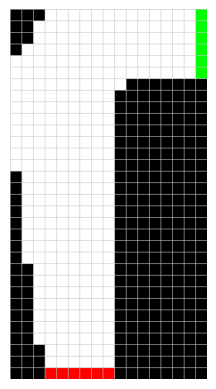


Circuito 2:


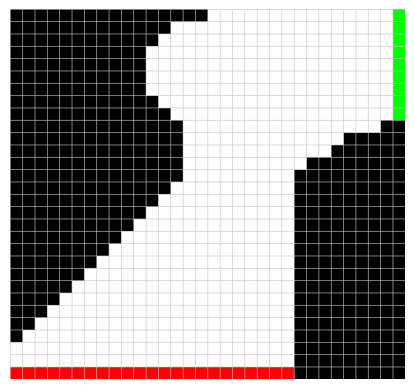

In [270]:
coche1 = Carrera(circuito1, 0.9, 0.1, -40)
img_pista1 = coche1.visualizar_circuito()
print('Circuito 1:')
plt.axis('off')
plt.imshow(img_pista1)
plt.show()

coche2 = Carrera(circuito2, 0.9, 0.1, -40)
img_pista2 = coche2.visualizar_circuito()
print('\nCircuito 2:')
plt.axis('off')
plt.imshow(img_pista2)
plt.show()

In [260]:
Q1, pi1, lista_recompensas1 = coche1.entrenar(500000, 10000)

Episodio 0
Episodio 10000
Episodio 20000
Episodio 30000
Episodio 40000
Episodio 50000
Episodio 60000
Episodio 70000
Episodio 80000
Episodio 90000
Episodio 100000
Episodio 110000
Episodio 120000
Episodio 130000
Episodio 140000
Episodio 150000
Episodio 160000
Episodio 170000
Episodio 180000
Episodio 190000
Episodio 200000
Episodio 210000
Episodio 220000
Episodio 230000
Episodio 240000
Episodio 250000
Episodio 260000
Episodio 270000
Episodio 280000
Episodio 290000
Episodio 300000
Episodio 310000
Episodio 320000
Episodio 330000
Episodio 340000
Episodio 350000
Episodio 360000
Episodio 370000
Episodio 380000
Episodio 390000
Episodio 400000
Episodio 410000
Episodio 420000
Episodio 430000
Episodio 440000
Episodio 450000
Episodio 460000
Episodio 470000
Episodio 480000
Episodio 490000


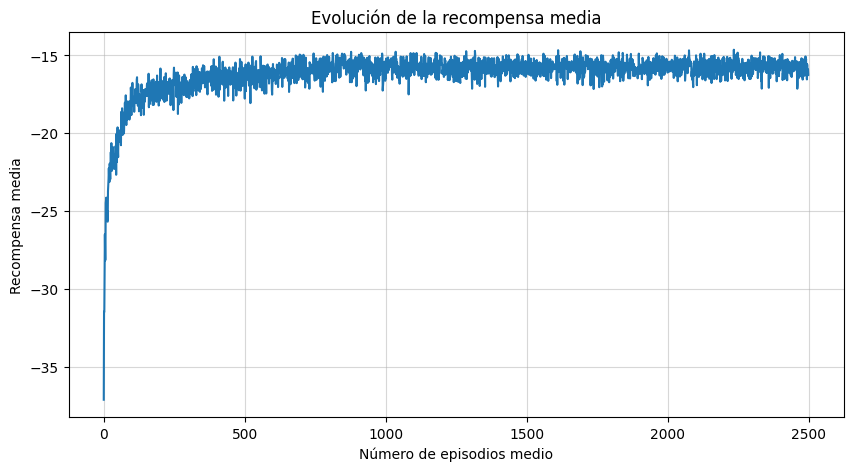

In [261]:
media_recompensas1 = np.array(lista_recompensas1)
k = 200

media_recompensas1 = media_recompensas1.reshape(-1, k).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(range(len(media_recompensas1[1:])), media_recompensas1[1:])
plt.grid(True, alpha=0.5)
plt.title('Evolución de la recompensa media')
plt.xlabel('Número de episodios medio')
plt.ylabel('Recompensa media')
plt.show()

[(6, 0, 0, 0), (7, 1, 1, 1), (7, 3, 0, 2), (7, 6, 0, 3), (7, 9, 0, 3), (8, 13, 1, 4), (8, 17, 0, 4), (8, 21, 0, 4), (8, 24, 0, 3), (9, 26, 1, 2), (11, 27, 2, 1), (13, 27, 2, 0), (16, 27, 3, 0)]


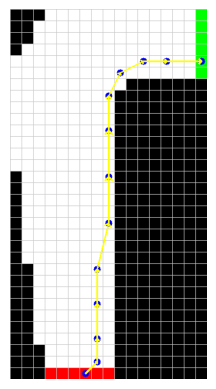

In [268]:
trayecto1 = coche1.test((6, 0), pi1)
print(trayecto1)

img_trayecto1 = coche1.visualizar_trayecto(trayecto1)
plt.axis('off')
plt.imshow(img_trayecto1)
plt.show()

In [247]:
Q2, pi2, lista_recompensas2 = coche2.entrenar(500000, 10000)

Episodio 0
Episodio 10000
Episodio 20000
Episodio 30000
Episodio 40000
Episodio 50000
Episodio 60000
Episodio 70000
Episodio 80000
Episodio 90000
Episodio 100000
Episodio 110000
Episodio 120000
Episodio 130000
Episodio 140000
Episodio 150000
Episodio 160000
Episodio 170000
Episodio 180000
Episodio 190000
Episodio 200000
Episodio 210000
Episodio 220000
Episodio 230000
Episodio 240000
Episodio 250000
Episodio 260000
Episodio 270000
Episodio 280000
Episodio 290000
Episodio 300000
Episodio 310000
Episodio 320000
Episodio 330000
Episodio 340000
Episodio 350000
Episodio 360000
Episodio 370000
Episodio 380000
Episodio 390000
Episodio 400000
Episodio 410000
Episodio 420000
Episodio 430000
Episodio 440000
Episodio 450000
Episodio 460000
Episodio 470000
Episodio 480000
Episodio 490000


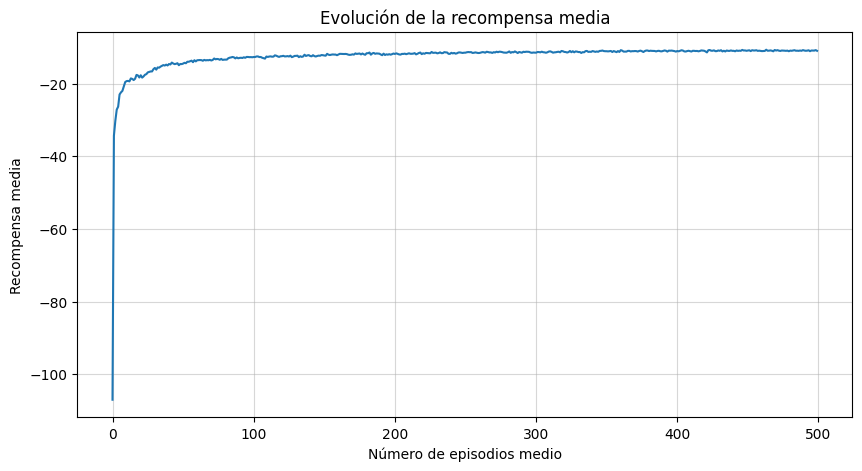

In [250]:
media_recompensas2 = np.array(lista_recompensas2)
k = 1000

media_recompensas2 = media_recompensas2.reshape(-1, k).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(range(len(media_recompensas2)), media_recompensas2)
plt.grid(True, alpha=0.5)
plt.title('Evolución de la recompensa media')
plt.xlabel('Número de episodios medio')
plt.ylabel('Recompensa media')
plt.show()

[(5, 0, 0, 0), (6, 1, 1, 1), (7, 2, 1, 1), (9, 3, 2, 1), (11, 5, 2, 2), (14, 8, 3, 3), (17, 11, 3, 3), (21, 15, 4, 4), (24, 18, 3, 3), (27, 22, 3, 4), (31, 25, 4, 3)]


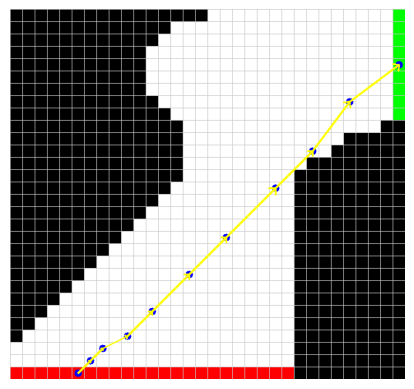

In [255]:
trayecto2 = coche2.test((5, 0), pi2)
print(trayecto2)

img_trayecto2 = coche2.visualizar_trayecto(trayecto2)
plt.axis('off')
plt.imshow(img_trayecto2)
plt.show()